In [1]:
import os
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import numpy as np
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from collections import defaultdict
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
img_dir  = "/kaggle/input/datasets/emmanueluc322/ima-segmentation-images/ISIC-images"
mask_dir = "/kaggle/input/datasets/emmanueluc322/ima-segmentation-images/segs"

In [3]:
all_masks       = os.listdir(mask_dir)
consensus_masks = {
    m.split("_")[0] + "_" + m.split("_")[1]: m
    for m in all_masks if "_ST_ST_ST_ST" in m
}
annotator_masks = defaultdict(list)
for m in all_masks:
    if "_ST_ST_ST_ST" not in m:
        isic_id = m.split("_")[0] + "_" + m.split("_")[1]
        annotator_masks[isic_id].append(m)

# build master dataframe
records = []
for img_file in os.listdir(img_dir):
    if not img_file.endswith(".jpg"):
        continue
    isic_id  = img_file.replace(".jpg", "")
    img_path = os.path.join(img_dir, img_file)
    ann_list = annotator_masks.get(isic_id, [])
    con_mask = consensus_masks.get(isic_id, None)
    num_ann  = len(ann_list)

    if num_ann == 0:
        continue   # skip images with no masks at all

    records.append({
        "isic_id":        isic_id,
        "img_path":       img_path,
        "annotator_masks": ann_list,
        "consensus_mask": con_mask,
        "num_annotators": num_ann,
        "has_consensus":  con_mask is not None,
    })

df = pd.DataFrame(records)
print(f"Total usable images : {len(df)}")
print(f"Single annotator    : {(df['num_annotators'] == 1).sum()}")
print(f"Multi annotator     : {(df['num_annotators'] > 1).sum()}")
print(f"Has consensus mask  : {df['has_consensus'].sum()}")


Total usable images : 14967
Single annotator    : 12573
Multi annotator     : 2394
Has consensus mask  : 2394


In [4]:
multi_df  = df[df["num_annotators"] > 1].reset_index(drop=True)
single_df = df[df["num_annotators"] == 1].reset_index(drop=True)

# split single-annotator images into train/val
train_single, val_single = train_test_split(
    single_df, test_size=0.15, random_state=42
)

# split multi-annotator images into val/test
# keep majority for test (multi-annotator evaluation)
val_multi, test_multi = train_test_split(
    multi_df, test_size=0.70, random_state=42
)

# combine
train_df = pd.concat([train_single],
                     ignore_index=True)
val_df   = pd.concat([val_single, val_multi],
                     ignore_index=True)
test_df  = test_multi.reset_index(drop=True)

print(f"\nSplit:")
print(f"  Train : {len(train_df):,}  "
      f"(single annotator only)")
print(f"  Val   : {len(val_df):,}  "
      f"(mixed)")
print(f"  Test  : {len(test_df):,}  "
      f"(multi-annotator — for IAA evaluation)")
print(f"\nTest multi-annotator distribution:")
print(test_df["num_annotators"].value_counts().sort_index())




Split:
  Train : 10,687  (single annotator only)
  Val   : 2,604  (mixed)
  Test  : 1,676  (multi-annotator — for IAA evaluation)

Test multi-annotator distribution:
num_annotators
3    1491
4     149
5      33
6       3
Name: count, dtype: int64


In [5]:
def build_soft_mask(mask_filenames, mask_dir, size=(224, 224)):
    """
    Average multiple annotator masks into a soft label map.
    Each pixel value = fraction of annotators who labeled it lesion.
    Range: 0.0 (all said background) to 1.0 (all said lesion)
    """
    accum = np.zeros(size, dtype=np.float32)
    valid = 0
    for fname in mask_filenames:
        path = os.path.join(mask_dir, fname)
        if not os.path.exists(path):
            continue
        mask = np.array(
            Image.open(path).convert("L").resize(
                size, Image.NEAREST
            )
        )
        # normalize to 0-1
        mask = (mask > 127).astype(np.float32)
        accum += mask
        valid += 1
    if valid == 0:
        return accum
    return accum / valid   # soft label: fraction who said lesion


In [6]:
class IMADataset(Dataset):
    def __init__(self, df, mask_dir,
                 img_size=224,
                 mode="train"):
        """
        mode = "train" — returns image + soft mask from
                         all available annotators
        mode = "val"   — returns image + single hard mask
        mode = "test"  — returns image + all annotator masks
                         for IAA evaluation
        """
        self.df       = df.reset_index(drop=True)
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.mode     = mode

        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])
        self.mask_transform = transforms.Compose([
            transforms.Resize(
                (img_size, img_size),
                interpolation=transforms.InterpolationMode.NEAREST
            ),
            transforms.ToTensor()
        ])
        if mode == "train":
            self.aug_transform = transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.5),
                transforms.RandomRotation(30),
                transforms.ColorJitter(
                    brightness=0.2, contrast=0.2,
                    saturation=0.2
                ),
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["img_path"]).convert("RGB")

        if self.mode == "train":
            # build soft mask from all annotators
            soft = build_soft_mask(
                row["annotator_masks"],
                self.mask_dir,
                size=(self.img_size, self.img_size)
            )
            image = self.img_transform(image)
            mask  = torch.FloatTensor(soft).unsqueeze(0)
            return image, mask

        elif self.mode == "val":
            # use first available mask as hard label
            mask_file = row["annotator_masks"][0]
            mask_path = os.path.join(self.mask_dir, mask_file)
            mask_img  = Image.open(mask_path).convert("L")
            image = self.img_transform(image)
            mask  = self.mask_transform(mask_img)
            mask  = (mask > 0.5).float()
            return image, mask

        else:  # test
            # return all annotator masks for IAA evaluation
            image      = self.img_transform(image)
            all_masks  = []
            for mf in row["annotator_masks"]:
                mp = os.path.join(self.mask_dir, mf)
                if os.path.exists(mp):
                    m = Image.open(mp).convert("L")
                    m = self.mask_transform(m)
                    m = (m > 0.5).float()
                    all_masks.append(m)
            return image, all_masks, row["isic_id"]

In [7]:
train_dataset = IMADataset(
    train_df, mask_dir, img_size=224, mode="train"
)
val_dataset   = IMADataset(
    val_df, mask_dir, img_size=224, mode="val"
)
test_dataset  = IMADataset(
    test_df, mask_dir, img_size=224, mode="test"
)

train_loader = DataLoader(
    train_dataset, batch_size=16,
    shuffle=True, num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=16,
    shuffle=False, num_workers=4, pin_memory=True
)
# test uses batch_size=1 because each image has
# different number of annotator masks
test_loader = DataLoader(
    test_dataset, batch_size=1,
    shuffle=False, num_workers=2
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test images   : {len(test_dataset)}")


Train batches : 668
Val batches   : 163
Test images   : 1676


In [8]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction,
                      bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels,
                      bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.shape
        avg = self.fc(self.avg_pool(x).view(b, c))
        mx  = self.fc(self.max_pool(x).view(b, c))
        return x * self.sigmoid(avg + mx).view(b, c, 1, 1)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size,
                                 padding=kernel_size // 2,
                                 bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg    = x.mean(dim=1, keepdim=True)
        mx     = x.max(dim=1, keepdim=True).values
        pooled = torch.cat([avg, mx], dim=1)
        return x * self.sigmoid(self.conv(pooled))


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16,
                 spatial_kernel=7):
        super().__init__()
        self.channel = ChannelAttention(channels, reduction)
        self.spatial = SpatialAttention(spatial_kernel)

    def forward(self, x):
        return self.spatial(self.channel(x))

print("CBAM modules defined")

CBAM modules defined


In [9]:
class ConvBlock(nn.Module):
    """Double conv block used in U-Net decoder"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class DSATSegmentation(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()

        # ── Encoder: InceptionV3 with intermediate features
        self.backbone = timm.create_model(
            "inception_v3",
            pretrained=True,
            features_only=True,   # returns multi-scale features
            out_indices=(0, 1, 2, 3, 4)
        )

        # get feature channel counts at each stage
        dummy   = torch.randn(1, 3, 224, 224)
        feats   = self.backbone(dummy)
        ch_list = [f.shape[1] for f in feats]
        print(f"Encoder feature channels: {ch_list}")
        print(f"Encoder feature shapes  : "
              f"{[tuple(f.shape) for f in feats]}")

        # ── CBAM at bottleneck (deepest encoder stage)
        self.cbam = CBAM(
            channels=ch_list[-1],
            reduction=16,
            spatial_kernel=7
        )

        # ── Transformer at bottleneck
        h_bot = feats[-1].shape[2]
        w_bot = feats[-1].shape[3]
        self.num_tokens  = h_bot * w_bot
        self.feature_dim = ch_list[-1]

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.feature_dim,
            nhead=8,
            dim_feedforward=2048,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=2
        )

        # ── Decoder: U-Net style upsampling with skip connections
        # decoder channels (top-down)
        dec_chs = [256, 128, 64, 32]

        self.dec4 = ConvBlock(ch_list[-1] + ch_list[-2],
                              dec_chs[0])
        self.dec3 = ConvBlock(dec_chs[0] + ch_list[-3],
                              dec_chs[1])
        self.dec2 = ConvBlock(dec_chs[1] + ch_list[-4],
                              dec_chs[2])
        self.dec1 = ConvBlock(dec_chs[2] + ch_list[-5],
                              dec_chs[3])

        # ── Final output head
        self.head = nn.Sequential(
            nn.Conv2d(dec_chs[3], 16, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, num_classes, 1),
            nn.Sigmoid()   # output in [0,1] — confidence map
        )

        self.ch_list = ch_list

    def forward(self, x):
        # ── Encoder: extract multi-scale features
        feats = self.backbone(x)
        s1, s2, s3, s4, s5 = feats
        # s1: shallowest (high res, low channels)
        # s5: deepest    (low res, high channels)

        # ── CBAM on bottleneck
        s5_att = self.cbam(s5)          # channel then spatial

        # ── Transformer on bottleneck tokens
        b, c, h, w = s5_att.shape
        tokens   = s5_att.flatten(2).permute(0, 2, 1)
        attended = self.transformer(tokens)
        # reshape back to spatial map
        s5_out   = attended.permute(0, 2, 1).view(b, c, h, w)

        # ── Decoder with skip connections
        d4 = F.interpolate(s5_out, size=s4.shape[2:],
                           mode="bilinear",
                           align_corners=False)
        d4 = self.dec4(torch.cat([d4, s4], dim=1))

        d3 = F.interpolate(d4, size=s3.shape[2:],
                           mode="bilinear",
                           align_corners=False)
        d3 = self.dec3(torch.cat([d3, s3], dim=1))

        d2 = F.interpolate(d3, size=s2.shape[2:],
                           mode="bilinear",
                           align_corners=False)
        d2 = self.dec2(torch.cat([d2, s2], dim=1))

        d1 = F.interpolate(d2, size=s1.shape[2:],
                           mode="bilinear",
                           align_corners=False)
        d1 = self.dec1(torch.cat([d1, s1], dim=1))

        # ── Upsample to input resolution
        out = F.interpolate(d1, size=(224, 224),
                            mode="bilinear",
                            align_corners=False)
        return self.head(out)   # (b, 1, 224, 224) in [0,1]


In [10]:
model = DSATSegmentation(num_classes=1)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters()
                   if p.requires_grad)
print(f"\nDSAT Segmentation Model")
print(f"Total parameters : {total_params:,}")
print(f"Trainable params : {trainable:,}")

# test forward pass
dummy = torch.randn(2, 3, 224, 224).to(device)
with torch.no_grad():
    out = model(dummy)
print(f"\nForward pass OK")
print(f"Input  shape: {tuple(dummy.shape)}")
print(f"Output shape: {tuple(out.shape)}")
# should print (2, 1, 224, 224)
print(f"Output range: [{out.min():.3f}, {out.max():.3f}]")
# should be between 0 and 1

model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

Encoder feature channels: [64, 192, 288, 768, 2048]
Encoder feature shapes  : [(1, 64, 109, 109), (1, 192, 52, 52), (1, 288, 25, 25), (1, 768, 12, 12), (1, 2048, 5, 5)]

DSAT Segmentation Model
Total parameters : 80,808,419
Trainable params : 80,808,419

Forward pass OK
Input  shape: (2, 3, 224, 224)
Output shape: (2, 1, 224, 224)
Output range: [0.350, 0.540]


In [11]:
def dice_loss(pred, target, smooth=1e-6):
    """
    Dice loss for segmentation.
    Works with soft labels (target in [0,1])
    pred   : (b, 1, h, w) — model sigmoid output
    target : (b, 1, h, w) — soft label or hard mask
    """
    pred   = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + smooth) / (
        pred.sum() + target.sum() + smooth
    )


def bce_dice_loss(pred, target, bce_weight=0.5):
    """
    Combined BCE + Dice loss.
    BCE handles pixel-level accuracy.
    Dice handles region overlap.
    """
    bce  = F.binary_cross_entropy(pred, target)
    dice = dice_loss(pred, target)
    return bce_weight * bce + (1 - bce_weight) * dice


print("Loss functions defined")


Loss functions defined


In [12]:
def dice_coefficient(pred, target, threshold=0.5, smooth=1e-6):
    """Dice coefficient for evaluation (hard prediction)"""
    pred_bin = (pred > threshold).float()
    pred_f   = pred_bin.view(-1)
    target_f = target.view(-1)
    intersection = (pred_f * target_f).sum()
    return ((2 * intersection + smooth) /
            (pred_f.sum() + target_f.sum() + smooth)).item()


def iou_score(pred, target, threshold=0.5, smooth=1e-6):
    """IoU / Jaccard index"""
    pred_bin = (pred > threshold).float()
    pred_f   = pred_bin.view(-1)
    target_f = target.view(-1)
    intersection = (pred_f * target_f).sum()
    union        = pred_f.sum() + target_f.sum() - intersection
    return ((intersection + smooth) /
            (union + smooth)).item()


print("Metrics defined")

Metrics defined


In [13]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=4,
    min_lr=1e-7
)
print("Optimizer and scheduler ready")

Optimizer and scheduler ready


In [14]:
def train_one_epoch(loader):
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    total        = 0

    for i, (images, masks) in enumerate(loader):
        images = images.to(device)
        masks  = masks.float().to(device)

        optimizer.zero_grad()
        preds = model(images)
        loss  = bce_dice_loss(preds, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        dice = dice_coefficient(
            preds.detach().cpu(),
            masks.cpu()
        )
        running_dice += dice
        total        += 1

        if i % 100 == 0:
            print(f"  Batch {i}/{len(loader)}  "
                  f"Loss: {running_loss/total:.4f}  "
                  f"Dice: {running_dice/total:.4f}")

    return running_loss / total, running_dice / total

In [15]:
def evaluate(loader):
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    running_iou  = 0.0
    total        = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks  = masks.float().to(device)
            preds  = model(images)
            loss   = bce_dice_loss(preds, masks)

            running_loss += loss.item()
            running_dice += dice_coefficient(
                preds.cpu(), masks.cpu()
            )
            running_iou  += iou_score(
                preds.cpu(), masks.cpu()
            )
            total += 1

    return (running_loss / total,
            running_dice / total,
            running_iou  / total)

In [16]:
def evaluate(loader):
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    running_iou  = 0.0
    total        = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks  = masks.float().to(device)
            preds  = model(images)
            loss   = bce_dice_loss(preds, masks)

            running_loss += loss.item()
            running_dice += dice_coefficient(
                preds.cpu(), masks.cpu()
            )
            running_iou  += iou_score(
                preds.cpu(), masks.cpu()
            )
            total += 1

    return (running_loss / total,
            running_dice / total,
            running_iou  / total)

In [17]:
EPOCHS       = 50
best_dice    = 0.0
patience     = 8
patience_ctr = 0
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)

history = {
    "train_loss": [], "train_dice": [],
    "val_loss":   [], "val_dice":   [], "val_iou": []
}

print("=" * 60)
print("  Training DSAT Segmentation on IMA++")
print("=" * 60)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 45)

    train_loss, train_dice = train_one_epoch(train_loader)
    val_loss, val_dice, val_iou = evaluate(val_loader)
    scheduler.step(val_dice)

    history["train_loss"].append(train_loss)
    history["train_dice"].append(train_dice)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["val_iou"].append(val_iou)

    print(f"\n  Train Loss : {train_loss:.4f}  |  "
          f"Train Dice : {train_dice:.4f}")
    print(f"  Val Loss   : {val_loss:.4f}  |  "
          f"Val Dice   : {val_dice:.4f}  |  "
          f"Val IoU    : {val_iou:.4f}")

    if val_dice > best_dice:
        best_dice    = val_dice
        patience_ctr = 0
        torch.save(
            model.state_dict(),
            "/kaggle/working/checkpoints/"
            "dsat_segmentation_ima_best.pth"
        )
        print(f"  ✓ Best model saved (Dice: {best_dice:.4f})")
    else:
        patience_ctr += 1
        print(f"  No improvement ({patience_ctr}/{patience})")
        if patience_ctr >= patience:
            print(f"\n  Early stopping at epoch {epoch+1}")
            break

print(f"\n{'═'*60}")
print(f"  {'Ep':<6} {'Tr Loss':<12} {'Tr Dice':<12} "
      f"{'Val Loss':<12} {'Val Dice':<12} {'Val IoU'}")
print(f"{'─'*60}")
for i in range(len(history["train_loss"])):
    marker = " ✓" if (
        history["val_dice"][i] == max(history["val_dice"])
    ) else ""
    print(f"  {i+1:<6} "
          f"{history['train_loss'][i]:<12.4f} "
          f"{history['train_dice'][i]:<12.4f} "
          f"{history['val_loss'][i]:<12.4f} "
          f"{history['val_dice'][i]:<12.4f} "
          f"{history['val_iou'][i]:.4f}{marker}")
print(f"{'═'*60}")
print(f"\n  Best Val Dice: {best_dice:.4f}")

  Training DSAT Segmentation on IMA++

Epoch 1/50
---------------------------------------------
  Batch 0/668  Loss: 0.7094  Dice: 0.0759
  Batch 100/668  Loss: 0.5340  Dice: 0.7335
  Batch 200/668  Loss: 0.4223  Dice: 0.7611
  Batch 300/668  Loss: 0.3512  Dice: 0.7768
  Batch 400/668  Loss: 0.3023  Dice: 0.7955
  Batch 500/668  Loss: 0.2734  Dice: 0.8020
  Batch 600/668  Loss: 0.2540  Dice: 0.8060

  Train Loss : 0.2419  |  Train Dice : 0.8107
  Val Loss   : 0.1460  |  Val Dice   : 0.8592  |  Val IoU    : 0.7591
  ✓ Best model saved (Dice: 0.8592)

Epoch 2/50
---------------------------------------------
  Batch 0/668  Loss: 0.2349  Dice: 0.6673
  Batch 100/668  Loss: 0.1257  Dice: 0.8616
  Batch 200/668  Loss: 0.1234  Dice: 0.8652
  Batch 300/668  Loss: 0.1192  Dice: 0.8695
  Batch 400/668  Loss: 0.1198  Dice: 0.8678
  Batch 500/668  Loss: 0.1206  Dice: 0.8665
  Batch 600/668  Loss: 0.1198  Dice: 0.8673

  Train Loss : 0.1188  |  Train Dice : 0.8686
  Val Loss   : 0.1291  |  Val Dice

In [18]:
print("\nRunning multi-annotator evaluation on test set...")

model.load_state_dict(torch.load(
    "/kaggle/working/checkpoints/"
    "dsat_segmentation_ima_best.pth",
    map_location=device
))
model.eval()

model_dice_scores = []
human_dice_scores = []
model_iou_scores  = []

with torch.no_grad():
    for images, all_masks, isic_ids in test_loader:
        image = images.to(device)
        pred  = model(image).squeeze(0).cpu()

        img_model_dices = []
        for ann_mask in all_masks:
            ann = ann_mask[0]
            d   = dice_coefficient(pred, ann)
            iou = iou_score(pred, ann)
            img_model_dices.append(d)
            model_iou_scores.append(iou)
        model_dice_scores.append(np.mean(img_model_dices))

        if len(all_masks) >= 2:
            for i in range(len(all_masks)):
                for j in range(i + 1, len(all_masks)):
                    m_i = all_masks[i][0]
                    m_j = all_masks[j][0]
                    d   = dice_coefficient(m_i, m_j)
                    human_dice_scores.append(d)

model_dice_mean = np.mean(model_dice_scores)
model_dice_std  = np.std(model_dice_scores)
human_dice_mean = np.mean(human_dice_scores)
human_dice_std  = np.std(human_dice_scores)
model_iou_mean  = np.mean(model_iou_scores)

print(f"\n{'═'*55}")
print(f"  Multi-Annotator Evaluation Results")
print(f"{'─'*55}")
print(f"  Model Dice (vs annotators) : "
      f"{model_dice_mean:.4f} ± {model_dice_std:.4f}")
print(f"  Human IAA Dice             : "
      f"{human_dice_mean:.4f} ± {human_dice_std:.4f}")
print(f"  Model IoU                  : "
      f"{model_iou_mean:.4f}")
print(f"{'─'*55}")
within_range = (
    model_dice_mean >= human_dice_mean - human_dice_std
)
print(f"  Model within human range   : {within_range}")
print(f"{'═'*55}")


Running multi-annotator evaluation on test set...

═══════════════════════════════════════════════════════
  Multi-Annotator Evaluation Results
───────────────────────────────────────────────────────
  Model Dice (vs annotators) : 0.8435 ± 0.1489
  Human IAA Dice             : 0.8503 ± 0.2000
  Model IoU                  : 0.7570
───────────────────────────────────────────────────────
  Model within human range   : True
═══════════════════════════════════════════════════════


Saved: /kaggle/working/visualizations/confidence_map_0.png


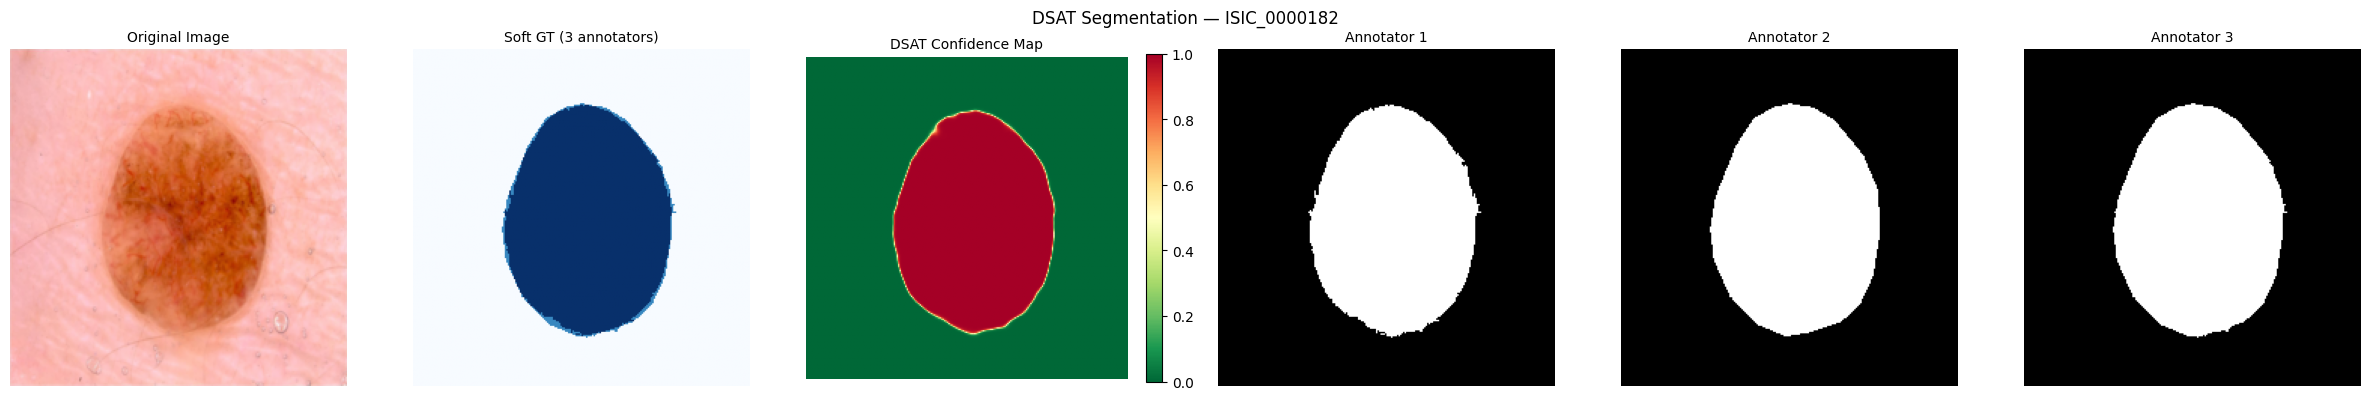

Saved: /kaggle/working/visualizations/confidence_map_1.png


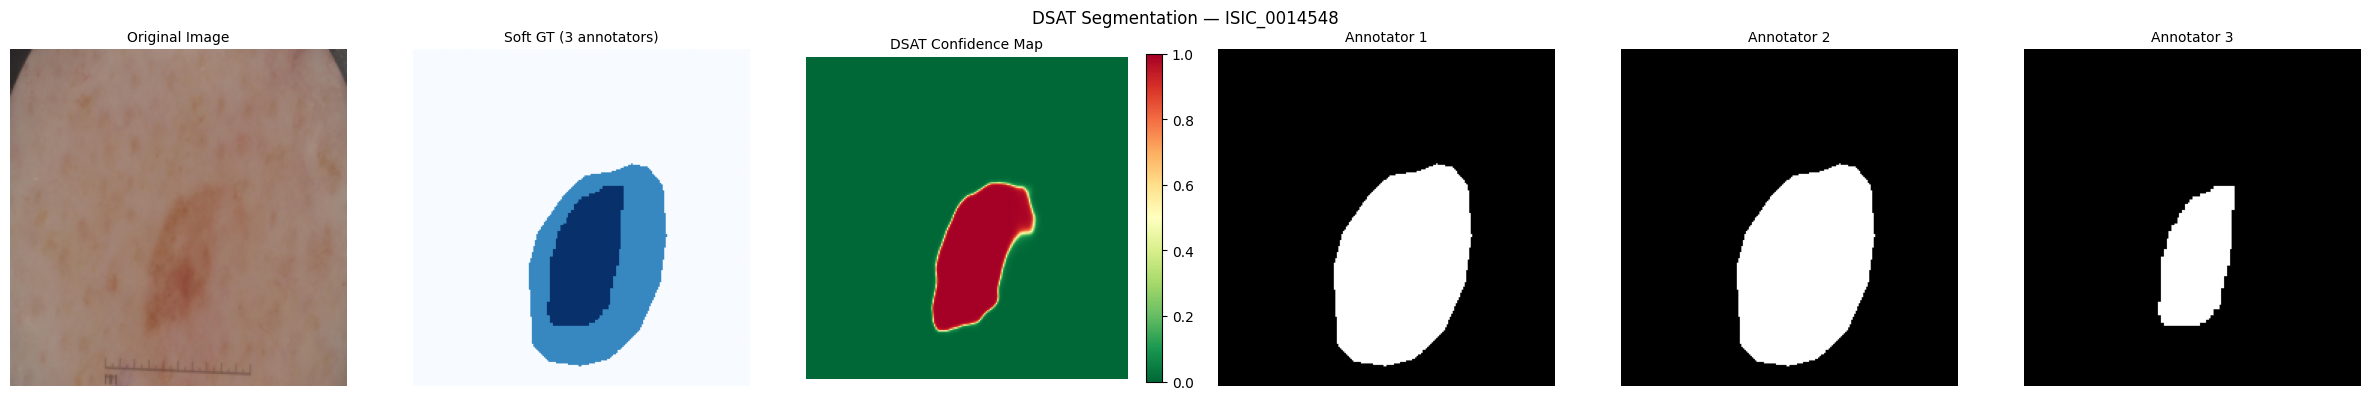

Saved: /kaggle/working/visualizations/confidence_map_2.png


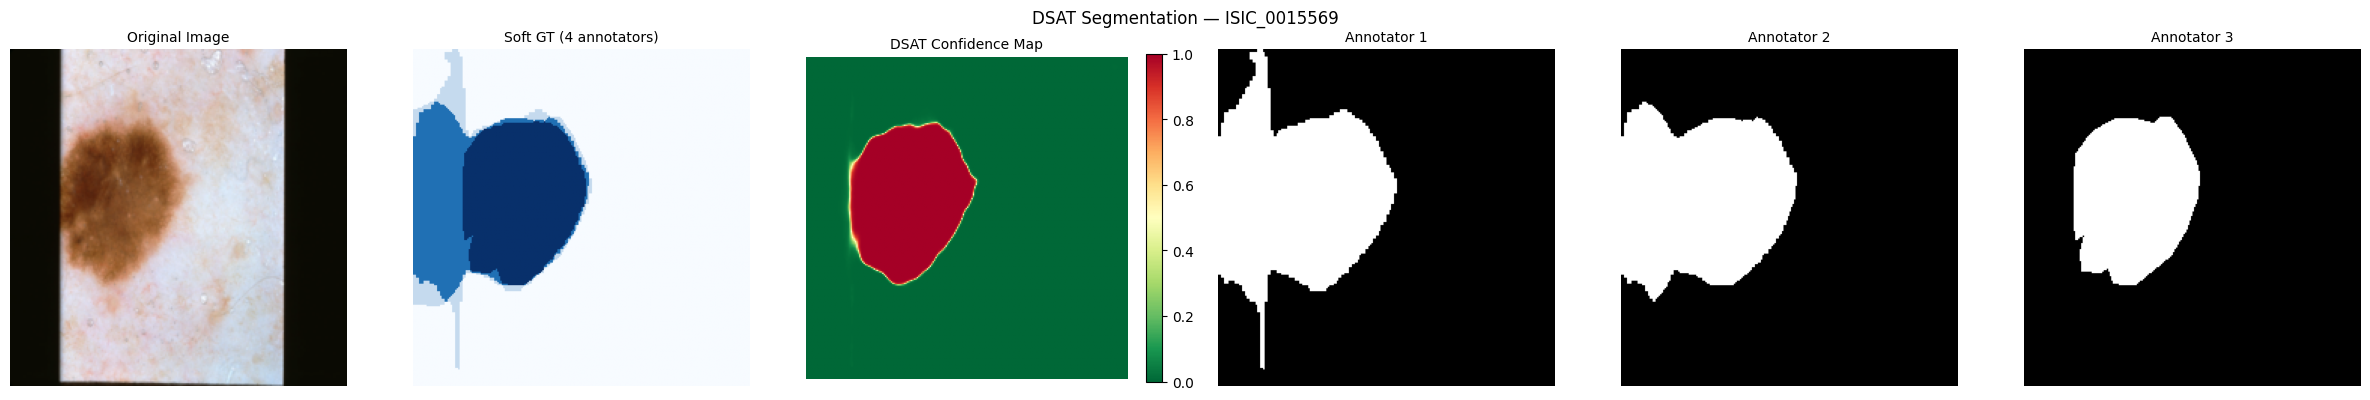

Saved: /kaggle/working/visualizations/confidence_map_3.png


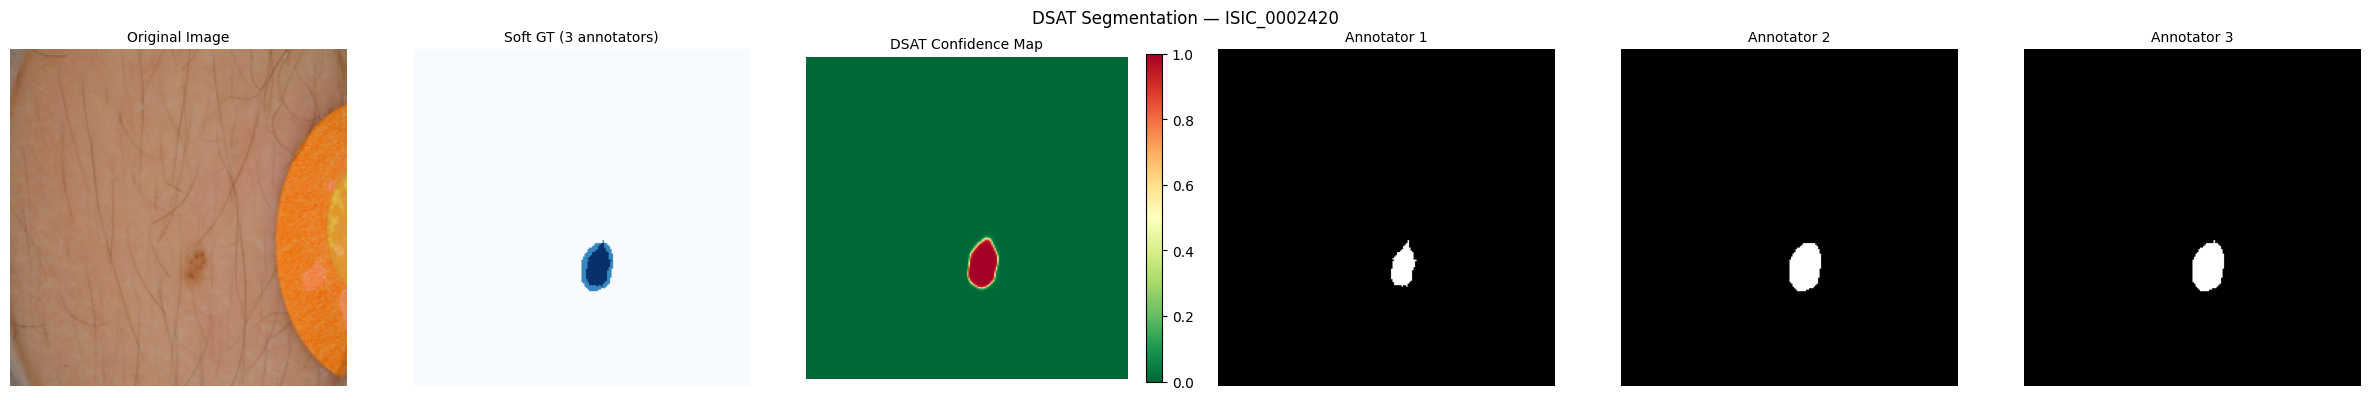

Saved: /kaggle/working/visualizations/confidence_map_4.png


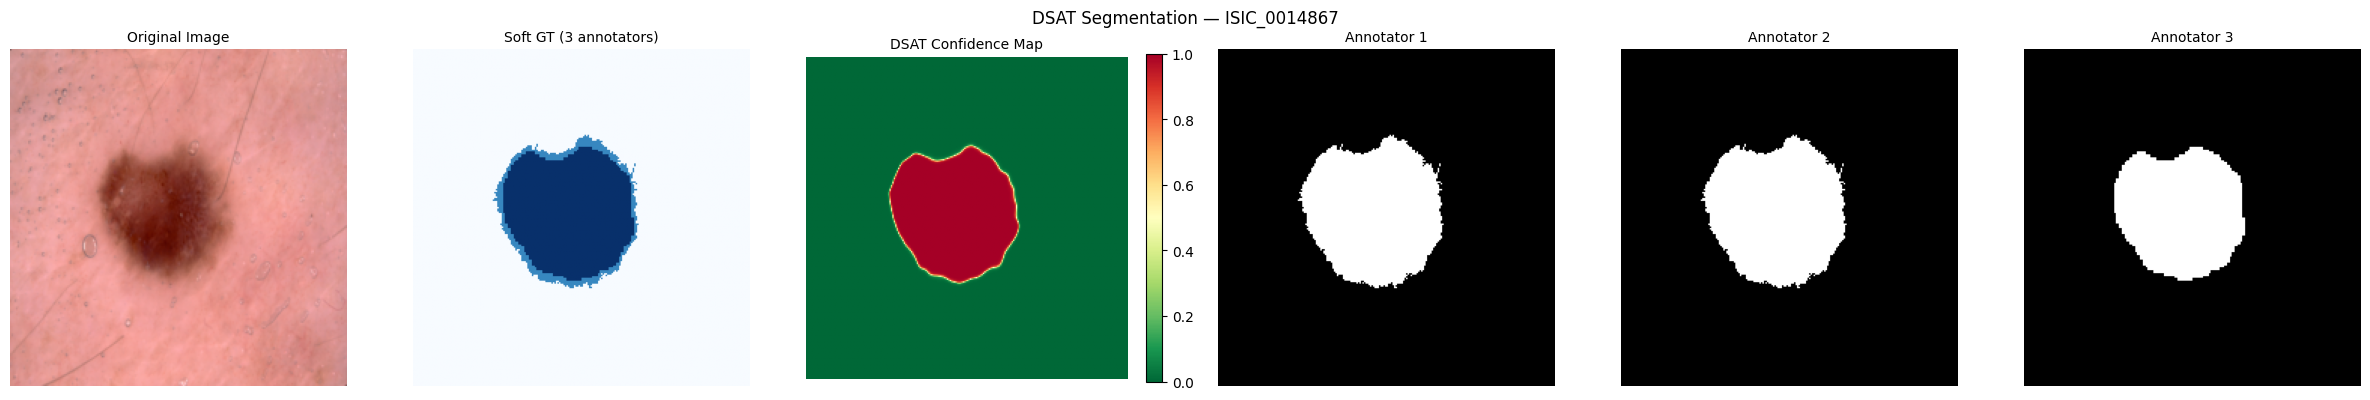

In [19]:
def visualize_confidence_map(model, dataset, idx=0,
                              save_path=None):
    model.eval()
    sample = dataset[idx]

    if dataset.mode == "test":
        image, masks, isic_id = sample
        image = image.unsqueeze(0).to(device)
        n_ann = len(masks)
    else:
        image, mask = sample
        image  = image.unsqueeze(0).to(device)
        masks  = [mask]
        n_ann  = 1
        isic_id = "sample"

    with torch.no_grad():
        pred = model(image).squeeze().cpu().numpy()

    img_np = image.squeeze().cpu().numpy().transpose(1, 2, 0)
    mean   = np.array([0.485, 0.456, 0.406])
    std    = np.array([0.229, 0.224, 0.225])
    img_np = np.clip(img_np * std + mean, 0, 1)

    soft_gt = np.zeros_like(pred)
    for m in masks:
        soft_gt += m.squeeze().numpy()
    soft_gt /= len(masks)

    ncols = 3 + min(n_ann, 3)
    fig, axes = plt.subplots(1, ncols,
                             figsize=(4 * ncols, 4))

    axes[0].imshow(img_np)
    axes[0].set_title("Original Image", fontsize=10)
    axes[0].axis("off")

    axes[1].imshow(soft_gt, cmap="Blues", vmin=0, vmax=1)
    axes[1].set_title(
        f"Soft GT ({n_ann} annotators)", fontsize=10
    )
    axes[1].axis("off")

    im = axes[2].imshow(pred, cmap="RdYlGn_r",
                        vmin=0, vmax=1)
    axes[2].set_title(
        "DSAT Confidence Map", fontsize=10
    )
    axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    for k, m in enumerate(masks[:3]):
        axes[3 + k].imshow(
            m.squeeze().numpy(), cmap="gray"
        )
        axes[3 + k].set_title(
            f"Annotator {k+1}", fontsize=10
        )
        axes[3 + k].axis("off")

    plt.suptitle(
        f"DSAT Segmentation — {isic_id}", fontsize=12
    )
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150,
                    bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()


os.makedirs("/kaggle/working/visualizations", exist_ok=True)
for i in range(min(5, len(test_dataset))):
    visualize_confidence_map(
        model, test_dataset, idx=i,
        save_path=(
            f"/kaggle/working/visualizations/"
            f"confidence_map_{i}.png"
        )
    )

In [20]:
print(f"\n{'═'*55}")
print(f"  DSAT Segmentation — Final Summary")
print(f"{'═'*55}")
print(f"  Architecture : DSAT (InceptionV3 + CBAM + Transformer)")
print(f"  Dataset      : IMA++ ({len(df):,} images)")
print(f"  Best Val Dice: {best_dice:.4f}")
print(f"  Model Dice   : {model_dice_mean:.4f} ± "
      f"{model_dice_std:.4f}")
print(f"  Human IAA    : {human_dice_mean:.4f} ± "
      f"{human_dice_std:.4f}")
print(f"  Model IoU    : {model_iou_mean:.4f}")
print(f"  Within human : {within_range}")
print(f"{'═'*55}")

print("\nCheckpoints saved:")
for f in os.listdir("/kaggle/working/checkpoints"):
    sz = os.path.getsize(
        f"/kaggle/working/checkpoints/{f}"
    ) / 1e6
    print(f"  {f}  ({sz:.1f} MB)")


═══════════════════════════════════════════════════════
  DSAT Segmentation — Final Summary
═══════════════════════════════════════════════════════
  Architecture : DSAT (InceptionV3 + CBAM + Transformer)
  Dataset      : IMA++ (14,967 images)
  Best Val Dice: 0.8824
  Model Dice   : 0.8435 ± 0.1489
  Human IAA    : 0.8503 ± 0.2000
  Model IoU    : 0.7570
  Within human : True
═══════════════════════════════════════════════════════

Checkpoints saved:
  dsat_segmentation_ima_best.pth  (323.6 MB)
